```
ConversationBufferMemory
ConversationBufferWindowMemory
ConversationTokenBufferMemory
ConversationSummaryMemory
ConversationSummaryBufferMemory
ConversationEntityMemory
VectorStoreRetrieverMemory
CombinedMemory
ConversationStringBufferMemory
```

```
Memory Management
│
├── Short-Term Memory
│      │
│      ├── Checkpointer
│      ├── Trim
│      ├── Delete
│      ├── Summarize
│      └── Custom filtering
│
└── Long-Term Memory
       │
       ├── Store.put()
       ├── Store.get()
       ├── Store.search()
       ├── user_id / namespace
       └── Semantic retrieval
```

```
Short-Term Memory
Checkpointer → current conversation/thread ka state save karta hai so same chat ko continue kar sake.
Trim → old messages hata kar sirf recent messages LLM ko bhejta hai to reduce tokens/cost.
Delete → selected messages ko memory/state se permanently remove karta hai.
Summarize → purani long conversation ko short summary me convert karta hai.
Custom filtering → apne rule se decide karte ho kaunse messages context me rakhne hain aur kaunse nahi.

Long-Term Memory
Store.put() → koi user fact/preference/memory save karta hai.
Store.get() → exact saved memory ko key/id se retrieve karta hai.
Store.search() → stored memories me search karke relevant memories nikalta hai.
user_id / namespace → memories ko different users ya categories ke according separate rakhta hai.
Semantic retrieval → exact keywords ke instead meaning/similarity ke basis par relevant memory retrieve karta hai.
```

```
Short-Term Memory
Checkpointer → Saves the state of the current conversation/thread so the same chat can be continued.
Trim → Removes old messages and sends only recent messages to the LLM to reduce tokens/cost.
Delete → Permanently removes selected messages from memory/state.
Summarize → Converts an old, lengthy conversation into a short summary.
Custom filtering → You decide, based on your own rules, which messages should be kept in the context and which should not.

Long-Term Memory
Store.put() → Saves a user fact/preference/memory.
Store.get() → Retrieves an exact saved memory using a key/ID.
Store.search() → Searches stored memories and retrieves relevant memories.
user_id / namespace → Separates memories according to different users or categories.
Semantic retrieval → Retrieves relevant memories based on meaning/similarity instead of exact keywords.
```

What is Memory in AI?

Memory is the mechanism that allows an AI application to retain and reuse information from previous interactions.

Memory in AI is the ability of an application to store, retrieve, and reuse information from previous interactions so that the system can maintain context and provide more consistent and personalized responses.

An LLM is usually stateless by itself. If the previous context is not provided with each new call, the model does not remember the earlier conversation.

User: My name is Sunny.

AI: Nice to meet you.

User: What is my name?

Without memory:

Every request → treated like a new conversation

With memory:

Previous Context

      +

Current Query

      ↓
      
Better Response

Example:

User: I am working on Agentic RAG.

Later: What project am I working on?

Memory ke through AI answer : Agentic RAG

Two major types

Short-Term Memory

→ current conversation/session

→ recent messages

Long-Term Memory

→ information retained across conversations

→ user preferences, facts, past interactions

Why do we need Memory Management in AI Applications?

- Maintain conversation continuity
- Handle follow-up questions
- Personalize responses
- Remember user preferences
- Support long-running agent workflows
- Avoid repeated questions
- Maintain context across sessions
- Track workflow state
- Control context-window usage
- Reduce token usage and cost

In [2]:
import os
from getpass import getpass

api_key = os.getenv("OPENAI_API_KEY")

if not api_key or api_key == "YOUR_OPENAI_API_KEY":
    os.environ["OPENAI_API_KEY"] = getpass("Enter OPENAI_API_KEY: ")

print("OPENAI_API_KEY configured:", bool(os.getenv("OPENAI_API_KEY")))

OPENAI_API_KEY configured: True


In [ ]:
from langchain.chat_models import init_chat_model

In [ ]:
model = init_chat_model("openai:gpt-4.1-mini")

In [ ]:
model.invoke([{"role": "user", "content": "Hello, how are you?"}])

In [ ]:
memory = []

In [ ]:
def chat(user_input:str)-> str:
    memory.append(
        {
            "role": "user",
            "content": user_input
        }
    )
    
    response = model.invoke(memory)
    
    memory.append(
        {
            "role": "assistant",
            "content": response.content
        }
    )
    return response.content


In [ ]:
def run_chat_loop():

    print("Type 'exit' or 'quit' to stop.")

    while True:
        user_input = input("\nYou: ").strip()

        if user_input.lower() in {"exit","quit",}:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print(
            "\nAI:",
            answer
        )


In [ ]:
run_chat_loop()

In [ ]:
memory

In [ ]:
for message in memory:
        print(
        message["role"],
        "->",
        message["content"]
    )

## Problem with Full Memory

If the conversation keeps growing, sending the entire history on every request increases:

- input tokens
- cost
- latency
- context-window usage

So we normally separate **what we store** from **what we send to the LLM**.

## Sliding Window Memory


We still store the complete conversation, but only the most recent messages are sent to the LLM.

**Stored history can be large; active LLM context should stay controlled.**

In [ ]:
# chatgpt

# 100 question

# 1
# 2
# 3
# 4
# 5





# 100

# 101 question 1 question sometime you will notice this chatgpt is hallucinating and giving wrong answer.

# 90 question
# 95 question

# then you will see that chatgpt is giving somewhat correct answer.

In [ ]:
full_history = [
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M7",
    "M8",
    "M9",
    "M10"
]


In [ ]:
recent_context = full_history[-6:]

In [ ]:
recent_context

In [ ]:
memory = []

In [ ]:
MAX_CONTEXT_MESSAGES = 6

In [ ]:
def chat(user_input: str) -> str:
    memory.append(
        {
            "role": "user",
            "content": user_input
        }
    )
    recent_context = memory[-MAX_CONTEXT_MESSAGES:]
    
    response = model.invoke(
        recent_context
    )
    memory.append(
        {
            "role": "assistant",
            "content": response.content
        }
    )
    return response.content
    

In [ ]:
def run_chat_loop():
    print("Type 'exit' or 'quit' to stop.")

    while True:
        user_input = input(
            "\nYou: "
        ).strip()

        if user_input.lower() in {
            "exit",
            "quit",
        }:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print(
            "\nAI:",
            answer
        )

        print(
            "\n[Full stored messages]:",
            len(memory)
        )

        print(
            "[Messages used as active context]:",
            min(
                len(memory),
                MAX_CONTEXT_MESSAGES,
            )
        )

In [ ]:
run_chat_loop()

# Summary + Recent Messages

Strategy:

- keep recent messages exactly as they are
- summarize older messages
- send `summary + recent messages` to the LLM
- optionally keep complete history separately for audit/storage

Compression happens only after a complete user/assistant turn, so we do not intentionally split a turn during summarization.

In [ ]:
memory = []

In [ ]:
conversation_summary = ""

In [ ]:
MAX_RECENT_MESSAGES = 6

In [ ]:
full_history = []

In [ ]:
def format_messages(messages):
    if not messages:
        return "No recent conversation."

    return "\n".join(
        f"{message['role']}: {message['content']}"
        for message in messages
    )
    


In [ ]:
def create_summary(old_summary: str, old_messages: list) -> str:

    conversation_text = format_messages(old_messages)

    prompt = f"""
You maintain conversation memory for an AI assistant.

Existing summary:
{old_summary or "No previous summary."}

Older conversation messages to merge:
{conversation_text}

Create one concise updated summary.

Preserve useful information such as:
- user name
- preferences
- projects
- decisions
- important facts
- important questions and answers

Ignore greetings and unnecessary small talk.
"""

    response = model.invoke(prompt)

    return response.content.strip()

In [ ]:
def compress_memory_into_summary():

    global memory
    global conversation_summary

    if len(memory) <= MAX_RECENT_MESSAGES:
        return

    old_messages = memory[:-MAX_RECENT_MESSAGES]

    memory = memory[-MAX_RECENT_MESSAGES:]

    conversation_summary = create_summary(
        conversation_summary,
        old_messages
    )

In [ ]:
def chat(user_input: str) -> str:

    global memory
    global full_history

    user_message = {"role": "user","content": user_input}

    memory.append(user_message)
    full_history.append(user_message)

    messages_for_llm = [{"role": "system", "content": f"""Previous conversation summary:{conversation_summary or "No previous summary."}"""},
                        *memory
                        ]
    
    response = model.invoke(messages_for_llm)

    assistant_message = {"role": "assistant","content": response.content}

    memory.append(assistant_message)
    full_history.append(assistant_message)

    # Compress only after a complete user/assistant turn
    compress_memory_into_summary()

    return response.content

In [ ]:
def chat_loop():

    print("Type 'exit' or 'quit' to stop.")

    while True:

        user_input = input("\nYou: ").strip()

        if user_input.lower() in {"exit","quit"}:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print("\nAI:",answer)

        print(
            "\n[Recent active messages]:",
            len(memory)
        )

        print(
            "[Full-history messages]:",
            len(full_history)
        )

        if conversation_summary:

            print(
                "\n[Current summary]:"
            )

            print(
                conversation_summary
            )

In [ ]:
chat_loop()

In [ ]:
state = {
    "memory": [],
    "summary": "",
    "full_history": []
}

In [ ]:
MAX_RECENT_MESSAGES = 6

In [ ]:
def create_summary(old_messages):

    conversation_text = "\n".join(
        f"{msg['role']}: {msg['content']}"
        for msg in old_messages
    )

    prompt = f"""
You maintain conversation memory for an AI assistant.

Existing summary:
{state["summary"] or "No previous summary."}

Older conversation:
{conversation_text}

Create one concise updated summary.
Preserve important facts, preferences, projects and decisions.
Ignore greetings and unnecessary small talk.
"""

    response = model.invoke(prompt)

    return response.content.strip()


In [ ]:

def compress_memory():

    if len(state["memory"]) <= MAX_RECENT_MESSAGES:
        return

    # Everything except the latest 6 messages
    old_messages = state["memory"][:-MAX_RECENT_MESSAGES]

    # Keep only latest 6 messages
    state["memory"] = state["memory"][-MAX_RECENT_MESSAGES:]

    # Merge old information into previous summary
    state["summary"] = create_summary(old_messages)

In [ ]:
def chat(user_input):

    # -------------------------
    # Store user message
    # -------------------------

    user_message = {
        "role": "user",
        "content": user_input
    }

    state["memory"].append(user_message)
    state["full_history"].append(user_message)


    # -------------------------
    # Send:
    # summary + recent messages
    # -------------------------

    messages = [
        {
            "role": "system",
            "content": f"""
Previous conversation summary:

{state["summary"] or "No previous summary."}
"""
        },
        *state["memory"]
    ]


    response = model.invoke(messages)


    # -------------------------
    # Store AI response
    # -------------------------

    assistant_message = {
        "role": "assistant",
        "content": response.content
    }

    state["memory"].append(assistant_message)
    state["full_history"].append(assistant_message)


    # Compress if memory becomes too large
    compress_memory()

    return response.content


In [ ]:
def chat_loop():

    while True:

        user_input = input("\nYou: ").strip()

        if user_input.lower() in {"exit", "quit"}:
            print("Chat ended.")
            break

        if not user_input:
            continue

        answer = chat(user_input)

        print("\nAI:", answer)

        print(
            "\nRecent messages:",
            len(state["memory"])
        )

        print(
            "Full history:",
            len(state["full_history"])
        )

        if state["summary"]:
            print(
                "\nCurrent Summary:\n",
                state["summary"]
            )

In [ ]:
chat_loop()

In [ ]:
state

| Step        | Actual conversation                                                                                                    | `memory` after turn     | Which messages are covered by the summary | `conversation_summary` after turn                                                                            | `full_history` |
| ----------- | ---------------------------------------------------------------------------------------------------------------------- | ----------------------- | --------------------------------------- | ------------------------------------------------------------------------------------------------------------ | -------------- |
| **M1-M2**   | **User:** My name is maha. **AI:** Nice to meet you, maha.                                                           | M1 M2                   | None                                    | Empty                                                                                                        | M1-M2          |
| **M3-M4**   | **User:** I live in Bengaluru. **AI:** Got it, you live in Bengaluru.                                                  | M1 M2 M3 M4             | None                                    | Empty                                                                                                        | M1-M4          |
| **M5-M6**   | **User:** I am learning LangGraph. **AI:** Great, LangGraph is useful for stateful agent workflows.                    | M1 M2 M3 M4 M5 M6       | None                                    | Empty                                                                                                        | M1-M6          |
| **M7-M8**   | **User:** I am building an Agentic RAG project. **AI:** Nice, that combines retrieval with agentic workflows.          | M3 M4 M5 M6 M7 M8       | **M1-M2**                               | **maha is the user's name.**                                                                                | M1-M8          |
| **M9-M10**  | **User:** My preferred programming language is Python. **AI:** Got it, you prefer Python.                              | M5 M6 M7 M8 M9 M10      | **M1-M4**                               | **maha is the user's name and he lives in Bengaluru.**                                                      | M1-M10         |
| **M11-M12** | **User:** I want to use PostgreSQL for persistence. **AI:** PostgreSQL is a good choice for persistent state and data. | M7 M8 M9 M10 M11 M12    | **M1-M6**                               | **maha is the user's name, lives in Bengaluru, and is learning LangGraph.**                                 | M1-M12         |
| **M13-M14** | **User:** I prefer concise explanations. **AI:** Understood, I will keep explanations concise.                         | M9 M10 M11 M12 M13 M14  | **M1-M8**                               | **maha lives in Bengaluru, is learning LangGraph, and is building an Agentic RAG project.**                 | M1-M14         |
| **M15-M16** | **User:** What am I currently building? **AI:** You are currently building an Agentic RAG project.                     | M11 M12 M13 M14 M15 M16 | **M1-M10**                              | **maha lives in Bengaluru, is learning LangGraph, is building an Agentic RAG project, and prefers Python.** | M1-M16         |


In [1]:
import os
from getpass import getpass
import faiss
import numpy as np
from langchain_openai import ChatOpenAI
from sentence_transformers import SentenceTransformer

e:\MAHA\AIPRO\Agentic7AM\myAgenticAI_7am_May26\myenv7amm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ============================================================
# OPENAI SETUP
# ============================================================

api_key = os.getenv("OPENAI_API_KEY")

if not api_key or api_key == "YOUR_OPENAI_API_KEY":
    api_key = getpass("Enter OPENAI_API_KEY: ").strip()
    if not api_key:
        raise ValueError("OPENAI_API_KEY is required.")
    os.environ["OPENAI_API_KEY"] = api_key

LLM_MODEL = "gpt-4o-mini"

model = ChatOpenAI(
    model=LLM_MODEL,
    temperature=0
)

In [ ]:
model.invoke([{"role": "user", "content": "Hello, how are you?"}])

In [ ]:

# ============================================================
# EMBEDDING MODEL + FAISS INDEX
# ============================================================

embedder = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

dimension = embedder.get_sentence_embedding_dimension()
print(dimension)

In [ ]:
dimension

In [ ]:
index = faiss.IndexFlatL2(dimension)

In [ ]:
documents = []

In [ ]:

# ============================================================
# SHORT-TERM CONVERSATION MEMORY
# ============================================================
memory = []

In [ ]:
# ============================================================
# CREATE EMBEDDING
# ============================================================
def embed(text):
    embedding = embedder.encode([text])[0]
    return embedding.astype("float32")

In [ ]:
# ============================================================
# ADD DOCUMENT TO VECTOR STORE
# ============================================================
def add_document(text):
    embedding = embed(text)
    index.add(np.array([embedding]))
    documents.append(text)

In [ ]:
# ============================================================
# RETRIEVE RELEVANT DOCUMENTS
# ============================================================

def retrieve(query, k=2):

    if not documents:
        return []

    query_embedding = embed(query)

    k = min(k, len(documents))

    distances, ids = index.search(
        np.array(
            [query_embedding]
        ),
        k
    )

    results = []

    for i in ids[0]:

        if i != -1:
            results.append(
                documents[i]
            )

    return results

In [ ]:

# ============================================================
# GENERATE ANSWER
# ============================================================

def generate_answer(
    query,
    retrieved_documents,
    memory
):

    # Convert previous conversation into text
    memory_text = "\n".join(
        f"User: {user_query}\n"
        f"Assistant: {assistant_answer}"
        for user_query, assistant_answer in memory
    )

    if not memory_text:
        memory_text = "No previous conversation."


    # Convert retrieved documents into text
    documents_text = "\n".join(
        retrieved_documents
    )

    if not documents_text:
        documents_text = "No relevant documents found."


    # Final prompt
    prompt = f"""
You are a helpful AI assistant.

Previous conversation:
{memory_text}

Relevant documents:
{documents_text}

Current user question:
{query}

Answer the user's question using the relevant documents
and previous conversation when useful.

If the answer is not available in the provided documents,
say that you do not know based on the provided documents.
"""


    # Call LLM
    response = model.invoke(prompt)


    return (
        response.content
        .strip()
    )


In [ ]:
# ============================================================
# SAMPLE KNOWLEDGE BASE
# ============================================================

# Make this cell safe to run multiple times.
index.reset()
documents.clear()

add_document(
    """
    Paris is the capital and largest city of France. The River Seine flows
    through the city and divides it into the Left Bank and the Right Bank.
    Paris is known for landmarks such as the Eiffel Tower, Notre-Dame
    Cathedral, the Arc de Triomphe, and the Champs-Elysees. It is also an
    important European centre for art, fashion, food, and architecture.
    """
)

add_document(
    """
    The Eiffel Tower is located on the Champ de Mars in Paris. Gustave
    Eiffel's company built it for the 1889 World's Fair. The tower is about
    330 metres tall and has observation levels that provide views across
    the city. Nearby attractions include the River Seine and the Trocadero
    gardens, making this area a popular stop for first-time visitors.
    """
)

add_document(
    """
    The Louvre Museum in Paris is one of the world's largest and most visited
    art museums. It is housed in a former royal palace and is recognized by
    the glass pyramid at its main entrance. Its collection includes the Mona
    Lisa, the Venus de Milo, and works from ancient Egypt, Greece, Rome, and
    later European periods. Visitors often need several hours to explore it.
    """
)

add_document(
    """
    Berlin is the capital and largest city of Germany. Major landmarks include
    the Brandenburg Gate, the Reichstag building, the Berlin Cathedral, and
    Museum Island. The Berlin Wall divided the city during the Cold War until
    1989, and the East Side Gallery now preserves a painted section of it.
    Berlin is especially known for its modern history, museums, and creative
    cultural scene.
    """
)

add_document(
    """
    Munich is the capital of Bavaria in southern Germany. The city is famous
    for Oktoberfest, which is generally held from late September into early
    October. Important places include Marienplatz, the Frauenkirche, the
    English Garden, and the Deutsches Museum. Munich is also a useful base
    for travellers interested in the Bavarian Alps and nearby castles.
    """
)

add_document(
    """
    Paris, Berlin, and Munich offer different travel experiences. Paris is a
    strong choice for classical art, iconic architecture, and French cuisine.
    Berlin is better suited to travellers interested in twentieth-century
    history, museums, and contemporary culture. Munich combines traditional
    Bavarian culture with access to nature and the Alps. High-speed and
    intercity trains connect these cities, although Paris to Berlin is the
    longest of the three main routes.
    """
)


In [ ]:
documents

In [ ]:
# ============================================================
# RAG + MEMORY CHAT LOOP
# ============================================================

def chat():

    print("RAG with Memory started.")

    print("Type 'exit' or 'quit' to stop.")


    while True:
        query = input(
            "\nUser: "
        ).strip()


        if query.lower() in {
            "exit",
            "quit"
        }:

            print("Chat ended.")
            break


        if not query:
            continue


        # Step 1: Retrieve relevant documents
        retrieved_docs = retrieve(query,k=3)


        # Step 2: Generate answer using
        # previous memory + retrieved documents + current query
        answer = generate_answer(query,retrieved_docs,memory)


        # Step 3: Store current interaction in memory
        memory.append(
            (
                query,
                answer
            )
        )


        # Step 4: Display answer
        print(
            "\nAssistant:",
            answer
        )


        # print(
        #     "\nRetrieved Documents:"
        # )

        # for doc in retrieved_docs:
        #     print(
        #         "-",
        #         doc
        #     )


        print(
            "\nMemory Size:",
            len(memory)
        )


In [ ]:

# ============================================================
# RUN APPLICATION
# ============================================================

chat()

In [ ]:
# 1. What are the main attractions in Paris?

# 2. Tell me more about the Eiffel Tower and the places located nearby.

# 3. Which museum in that city contains the Mona Lisa?

# 4. Compare Berlin and Munich for a traveller.

# 5. Out of those two German cities, which one should I choose if I want to visit the Alps, and why?

In [ ]:
# ============================================================
# VIEW CONVERSATION MEMORY
# Run this cell after exiting the chat loop.
# ============================================================

if not memory:
    print("Memory is empty. Ask some questions first.")
else:
    print(f"Total conversation turns: {len(memory)}")

    for turn_number, (question, answer) in enumerate(
        memory,
        start=1
    ):
        print(f"\n--- Turn {turn_number} ---")
        print("User:", question)
        print("Assistant:", answer)


In [ ]:
# ============================================================
# CONVERSATION MEMORY
# Summary + Recent Messages
# ============================================================

class ConversationMemory:

    def __init__(
        self,
        model,
        max_recent_messages=6
    ):

        self.model = model

        self.max_recent_messages = (
            max_recent_messages
        )

        self.memory = []

        self.summary = ""

        self.full_history = []


    # --------------------------------------------------------
    # CREATE / UPDATE SUMMARY
    # --------------------------------------------------------

    def create_summary(
        self,
        old_messages
    ):

        conversation_text = "\n".join(
            f"{msg['role']}: {msg['content']}"
            for msg in old_messages
        )


        prompt = f"""
You maintain conversation memory for an AI assistant.

Existing summary:
{self.summary or "No previous summary."}

Older conversation:
{conversation_text}

Create one concise updated summary.

Preserve:
- important facts
- user preferences
- projects
- decisions
- important previous context

Ignore:
- greetings
- unnecessary small talk
"""


        response = self.model.invoke(
            prompt
        )


        return response.content.strip()


    # --------------------------------------------------------
    # COMPRESS MEMORY
    # --------------------------------------------------------

    def compress(self):

        if (
            len(self.memory)
            <= self.max_recent_messages
        ):
            return


        # Everything except latest messages
        old_messages = self.memory[
            :-self.max_recent_messages
        ]


        # Keep latest messages
        self.memory = self.memory[
            -self.max_recent_messages:
        ]


        # Update summary
        self.summary = (
            self.create_summary(
                old_messages
            )
        )


    # --------------------------------------------------------
    # ADD USER MESSAGE
    # --------------------------------------------------------

    def add_user_message(
        self,
        content
    ):

        message = {
            "role": "user",
            "content": content
        }


        self.memory.append(
            message
        )


        self.full_history.append(
            message
        )


    # --------------------------------------------------------
    # ADD ASSISTANT MESSAGE
    # --------------------------------------------------------

    def add_assistant_message(
        self,
        content
    ):

        message = {
            "role": "assistant",
            "content": content
        }


        self.memory.append(
            message
        )


        self.full_history.append(
            message
        )


    # --------------------------------------------------------
    # GET RECENT CONVERSATION
    # --------------------------------------------------------

    def get_recent_conversation(self):

        if not self.memory:
            return "No recent conversation."


        return "\n".join(
            f"{msg['role']}: {msg['content']}"
            for msg in self.memory
        )

In [ ]:
# ============================================================
# RAG ASSISTANT
# ============================================================

class RAGAssistant:

    def __init__(self, model, retriever, max_recent_messages=6):

        self.model = model

        self.retriever = retriever


        self.memory = ConversationMemory(model=model,max_recent_messages=(max_recent_messages ))


    # --------------------------------------------------------
    # QUERY REWRITING
    # --------------------------------------------------------

    def rewrite_query(self,user_query):

        recent_conversation = (self.memory.get_recent_conversation())
        
        prompt = f"""
You rewrite conversational questions into
standalone search queries.

Conversation summary:
{self.memory.summary or "No previous summary."}

Recent conversation:
{recent_conversation}

Current user question:
{user_query}

Rewrite the current question as a complete,
standalone search query.

Return only the rewritten query.
"""
        response = self.model.invoke(prompt)

        return response.content.strip()

    # --------------------------------------------------------
    # RETRIEVE DOCUMENTS
    # --------------------------------------------------------

    def retrieve_documents(self,query):

        documents = (
            self.retriever.invoke(
                query
            )
        )


        return documents


    # --------------------------------------------------------
    # FORMAT DOCUMENTS
    # --------------------------------------------------------

    def format_documents(self, documents):

        if not documents:
            return "No relevant documents found."

        return "\n\n".join(
            doc.page_content
            for doc in documents
        )


    # --------------------------------------------------------
    # GENERATE FINAL ANSWER
    # --------------------------------------------------------

    def generate_answer(
        self,
        user_query,
        documents
    ):

        document_context = (
            self.format_documents(
                documents
            )
        )


        messages = [

            {
                "role": "system",
                "content": f"""
You are a helpful RAG assistant.

Previous conversation summary:

{self.memory.summary or "No previous summary."}

Use the conversation memory for context
and use the retrieved documents for
factual information.

Retrieved documents:

{document_context}

If the answer is not available in the
retrieved documents, say that you do not
know based on the available documents.
"""

""
            },

{
    "role": "user",
    "content": user_query
},
            *self.memory.memory
        ]


        response = self.model.invoke(
            messages
        )


        return response.content


    # --------------------------------------------------------
    # COMPLETE RAG PIPELINE
    # --------------------------------------------------------

    def chat(
        self,
        user_input
    ):

        # --------------------------------------
        # 1. Store user message
        # --------------------------------------

        self.memory.add_user_message(
            user_input
        )


        # --------------------------------------
        # 2. Rewrite conversational query
        # --------------------------------------

        standalone_query = (
            self.rewrite_query(
                user_input
            )
        )


        # --------------------------------------
        # 3. Retrieve relevant documents
        # --------------------------------------

        documents = (
            self.retrieve_documents(
                standalone_query
            )
        )


        # --------------------------------------
        # 4. Generate final answer
        # --------------------------------------

        answer = (
            self.generate_answer(
                standalone_query,
                documents
            )
        )


        # --------------------------------------
        # 5. Store AI response
        # --------------------------------------

        self.memory.add_assistant_message(
            answer
        )


        # --------------------------------------
        # 6. Compress old memory
        # --------------------------------------

        self.memory.compress()


        return {
            "answer": answer,
            "standalone_query": standalone_query,
            "documents": documents
        }

# Data Ingestion

In [ ]:
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore


# ============================================================
# 1. SAMPLE DOCUMENTS (Data)
# ============================================================

documents = [

    Document(
        page_content="""
        ANNUAL LEAVE POLICY: Confirmed full-time employees receive 20 days of
        paid annual leave during each calendar year. Annual leave becomes
        available after the employee completes probation and is credited on
        a pro-rata basis for employees joining mid-year. Leave requests of
        three or more consecutive working days should normally be submitted
        at least two weeks in advance. A maximum of five unused days may be
        carried into the next calendar year and must be used by March 31.
        """
    ),

    Document(
        page_content="""
        PROBATION POLICY: The standard probation period for a new employee is
        six months from the date of joining. The manager conducts reviews near
        the third and sixth month to discuss performance, attendance, and role
        expectations. If additional evaluation is required, probation may be
        extended once for up to three months with written reasons. Employees
        receive confirmation in writing after successfully completing the
        probation review.
        """
    ),

    Document(
        page_content="""
        SICK LEAVE POLICY: Full-time employees receive 10 paid sick-leave days
        per calendar year. Employees should inform their manager as early as
        possible on the day of absence. A medical certificate is required for
        more than two consecutive working days of sick leave. Unused sick leave
        expires at the end of the year and cannot be carried forward or paid
        out. Extended medical absence is reviewed separately by Human Resources.
        """
    ),

    Document(
        page_content="""
        BUSINESS TRAVEL POLICY: Business travel must be approved by the
        employee's manager before tickets or accommodation are booked. Eligible
        expenses include economy airfare, rail travel, hotels within the city
        limit, local transportation, and reasonable meals. Employees must file
        the reimbursement claim within 30 days after completing the trip and
        attach itemized receipts. Late claims require written approval from the
        department head and may be rejected by Finance.
        """
    ),

    Document(
        page_content="""
        HOME-OFFICE EQUIPMENT POLICY: Remote and hybrid employees may claim up
        to $500 once every three years for approved home-office equipment.
        Eligible purchases include a monitor, keyboard, mouse, headset, desk,
        and ergonomic chair. Employees must obtain manager approval before a
        purchase and submit the receipt through the expense portal. Computers
        are issued separately by the company and are not covered by this
        allowance. Reimbursed equipment remains company property.
        """
    ),

    Document(
        page_content="""
        HYBRID WORK POLICY: Employees assigned to a hybrid role may work remotely
        for up to three days per week. Teams select common office days so that
        meetings and collaborative work can happen in person. Employees must
        remain available during the core collaboration hours of 10:00 AM to
        4:00 PM in their local time zone. Working permanently from another city
        or country requires prior approval from Human Resources and Tax.
        """
    ),

    Document(
        page_content="""
        WORKING HOURS POLICY: A standard full-time workweek consists of 40 hours,
        normally spread across Monday through Friday. Employees may choose their
        start and finish times with manager agreement, provided they attend
        required meetings and remain available during core collaboration hours.
        Overtime should be approved in advance. Employees are expected to record
        working time and absences accurately in the company attendance system.
        """
    ),

    Document(
        page_content="""
        LEARNING AND DEVELOPMENT POLICY: After completing probation, employees
        may use an annual learning budget of up to $1,200 for job-related courses,
        certifications, books, or conferences. The employee must explain how the
        activity supports their current role or development plan and receive
        manager approval before registration. Proof of completion and receipts
        are required for reimbursement. Unused learning budget does not carry
        into the following year.
        """
    ),

    Document(
        page_content="""
        HEALTH INSURANCE POLICY: Company health insurance begins on the employee's
        first day of employment. The standard plan covers the employee, one spouse
        or registered partner, and up to two dependent children. Employees must
        add eligible dependants within 30 days of joining or during the annual
        enrollment window. Optional coverage for parents is available at the
        employee's own cost. Claim procedures and hospital networks are listed
        in the insurer's online portal.
        """
    ),

    Document(
        page_content="""
        PERFORMANCE AND SEPARATION POLICY: Formal performance reviews take place
        twice each year, with a goal-setting review in January and a progress
        review in July. Promotion and bonus decisions consider performance,
        business results, skills, and role availability. An employee resigning
        during probation normally gives 30 days' notice; a confirmed employee
        normally gives 60 days' notice. Human Resources calculates the final
        settlement, including eligible unused annual leave.
        """
    )
]


In [ ]:
# ============================================================
# 2. EMBEDDING MODEL
# ============================================================

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small"
)

In [ ]:
# ============================================================
# 3. VECTOR STORE
# ============================================================

vector_store = InMemoryVectorStore(
    embedding=embeddings
)


# Add documents into vector store

vector_store.add_documents(
    documents
)

In [ ]:
# ============================================================
# 4. CREATE RETRIEVER
# ============================================================

retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 3
    }
)

In [ ]:
rag = RAGAssistant(
    model=model,
    retriever=retriever,
    max_recent_messages=6
)

In [ ]:
while True:

    user_input = input(
        "\nYou: "
    ).strip()


    if user_input.lower() in {
        "exit",
        "quit"
    }:

        print(
            "Chat ended."
        )

        break


    if not user_input:
        continue


    result = rag.chat(
        user_input
    )


    print(
        "\nStandalone Query:",
        result["standalone_query"]
    )


    print(
        "\nAI:",
        result["answer"]
    )


    print(
        "\nRecent Messages:",
        len(rag.memory.memory)
    )


    print(
        "Full History:",
        len(
            rag.memory.full_history
        )
    )


    if rag.memory.summary:

        print(
            "\nCurrent Summary:\n",
            rag.memory.summary
        )

In [ ]:
# ============================================================
# QUESTIONS TO TEST HR-POLICY RAG + MEMORY
# Ask these in the same chat session and in this order.
# ============================================================

# 1. How many annual leave days do confirmed employees receive, and what are the carry-forward rules?

# 2. Explain the probation period and when it can be extended.

# 3. After completing it, what learning benefit becomes available?

# 4. Compare the approval and reimbursement requirements for business travel and home-office equipment.

# 5. If I work in a hybrid role, how many days can I work remotely, and during which hours must I remain available?


In [ ]:
# ============================================================
# VIEW RAG CONVERSATION MEMORY
# Run this cell after typing exit in the chat loop.
# ============================================================

def show_rag_memory():

    print("\n========== MEMORY SUMMARY ==========")
    print(
        rag.memory.summary
        or "No summary created yet."
    )

    print("\n========== RECENT MEMORY ==========")

    if not rag.memory.memory:
        print("No recent messages stored.")
    else:
        for message_number, message in enumerate(
            rag.memory.memory,
            start=1
        ):
            print(
                f"{message_number}. "
                f"{message['role'].title()}: "
                f"{message['content']}"
            )

    print("\n========== FULL HISTORY ==========")

    if not rag.memory.full_history:
        print("No conversation history stored.")
    else:
        for message_number, message in enumerate(
            rag.memory.full_history,
            start=1
        ):
            print(
                f"{message_number}. "
                f"{message['role'].title()}: "
                f"{message['content']}"
            )


show_rag_memory()


## Memory management in Langgraph

In [10]:

# ============================================================
# MODEL
# ============================================================
from langchain.chat_models import init_chat_model

model = init_chat_model(
    "openai:gpt-4.1-mini",
    temperature=0
)

In [14]:
# ============================================================
# SHORT-TERM MEMORY
# ============================================================

from langgraph.checkpoint.memory import (
    InMemorySaver
)

checkpointer = InMemorySaver()

In [15]:
# ============================================================
# LONG-TERM MEMORY
# ============================================================

from langgraph.store.memory import (
    InMemoryStore
)

store = InMemoryStore(
    index={
        "dims": 1536,
        "embed": "openai:text-embedding-3-small"
    }
)

Here:

embed tells the store which embedding model to use to convert memories into vectors.

dims tells the store the size of the embedding vector produced by that model.

For text-embedding-3-small, the default embedding size is commonly 1536 dimensions, so we specify:

"dims": 1536

Why do we need this?

Suppose we save:

"User prefers Python for AI development."

The store converts it into an embedding vector:

[0.021, -0.183, 0.442, ...]

with 1536 values.

Later the user asks:

"Which programming language do I prefer?"

That query is also converted into an embedding, and the store compares the two vectors to find semantically similar memories.

```
Memory text
   ↓
Embedding model
   ↓
1536-dimensional vector
   ↓
Store

Current query
   ↓
Embedding model
   ↓
1536-dimensional vector
   ↓
Similarity search
   ↓
Relevant memories
```

In [16]:
# ============================================================
# AUTOMATIC MEMORY MANAGER
# ============================================================

from langmem import create_memory_store_manager

memory_manager = create_memory_store_manager(
    
    "openai:gpt-4.1-mini",

    namespace=(
        "memories",
        "{user_id}"
    ),

    instructions="""
Extract useful long-term information about the user.

Store:
- user preferences
- important personal facts
- goals
- projects
- decisions

Ignore greetings,
temporary questions,
and unnecessary small talk.
"""
)

Model decides, instructions guide what to remember, and namespace decides where that memory belongs.

A namespace is a logical path used to group and isolate related memories in the Store.

A namespace is a logical path used to organize and isolate related memories in a Store.

namespace = (
    "users",
    "maha_123",
    "memories"
)

Think of it like:

users
└── maha_123
    └── memories

When we save:

store.put(
    namespace,
    "memory_1",
    {
        "content": "User prefers Python"
    }
)

it means:

namespace = WHERE the memory is stored
key       = WHICH memory
value     = WHAT the memory contains

Conceptually:

users/
└── maha_123/
    └── memories/
        └── memory_1
            └── User prefers Python

A different user can have a different namespace, so their memories remain isolated.


model
→ which LLM should decide what information is important enough to remember

namespace
→ where the memories should be stored in the Store / under which user

instructions
→ what the LLM should store and what it should ignore

In your code:

"openai:gpt-4.1-mini"

This is the LLM used for memory extraction and updates.

namespace=(
    "memories",
    "{user_id}"
)

This defines where the memories should be stored.

For example:

memories/
└── maha_123

or:

memories/
└── manish_456

So each user's memories remain separated.

And:

instructions="""
Extract useful long-term information...
"""

This acts as the memory policy. It tells the memory manager what should be stored and what should be ignored.

Store:
- preferences
- goals
- projects

Ignore:
- greetings
- temporary questions

In [ ]:
# # ============================================================
# # CHATBOT NODE
# # ============================================================

# def chatbot(state: MessagesState):

#     config = get_config()

#     current_store = get_store()

#     user_id = (
#         config["configurable"]["user_id"]
#     )


#     # ----------------------------------------
#     # Current user query
#     # ----------------------------------------

#     user_query = (
#         state["messages"][-1].content
#     )


#     # ----------------------------------------
#     # Search relevant long-term memories
#     # ----------------------------------------

#     memories = current_store.search(

#         (
#             "memories",
#             user_id
#         ),

#         query=user_query,

#         limit=5
#     )


#     memory_text = "\n".join(
#         str(memory.value)
#         for memory in memories
#     )


#     if not memory_text:
#         memory_text = (
#             "No relevant long-term memories."
#         )


#     # ----------------------------------------
#     # System prompt with long-term memory
#     # ----------------------------------------

#     system_message = {
#         "role": "system",
#         "content": f"""
# You are a helpful AI assistant.

# Relevant long-term memories about the user:

# {memory_text}

# Use these memories only when relevant.
# """
#     }


#     # ----------------------------------------
#     # LLM Call
#     #
#     # state["messages"] already contains
#     # current thread history because of
#     # the checkpointer.
#     # ----------------------------------------

#     response = model.invoke(
#         [
#             system_message,
#             *state["messages"]
#         ]
#     )


#     return {
#         "messages": [
#             response
#         ]
#     }

In [19]:
from langgraph.graph import MessagesState

from langgraph.config import (
    get_store,
    get_config
)

DEBUG = True

def chatbot(state: MessagesState):

    config = get_config()
    current_store = get_store()

    configurable = config.get("configurable", {})

    user_id = configurable.get("user_id")
    thread_id = configurable.get("thread_id")

    namespace = (
        "memories",
        user_id
    )

    user_query = (
        state["messages"][-1].content
    )


    # ========================================================
    # SEARCH LONG-TERM MEMORY
    # ========================================================

    memories = current_store.search(
        namespace,
        query=user_query,
        limit=5
    )


    memory_text = "\n".join(
        str(memory.value)
        for memory in memories
    )

    if not memory_text:
        memory_text = (
            "No relevant long-term memories."
        )


    # ========================================================
    # DEBUG
    # ========================================================

    if DEBUG:

        print("\n" + "=" * 60)
        print("DEBUG INFO")
        print("=" * 60)

        print("Configurable :", configurable)
        print("User ID      :", user_id)
        print("Thread ID    :", thread_id)
        print("Namespace    :", namespace)
        print("User Query   :", user_query)

        print(
            "Thread Messages:",
            len(state["messages"])
        )

        print("\nCurrent Thread History:")

        for message in state["messages"]:
            print(
                f"- {message.type}: "
                f"{message.content}"
            )


        print(
            "\nRetrieved Memories:",
            len(memories)
        )

        for memory in memories:
            print(
                "-",
                memory.value
            )


        print("\nMemory Context:")
        print(memory_text)


    # ========================================================
    # SYSTEM PROMPT
    # ========================================================

    system_message = {
        "role": "system",
        "content": f"""
You are a helpful AI assistant.

Relevant long-term memories:

{memory_text}

Use these memories only when relevant.
"""
    }


    # ========================================================
    # LLM CALL
    # ========================================================

    response = model.invoke(
        [
            system_message,
            *state["messages"]
        ]
    )


    if DEBUG:

        print(
            "\nLLM Response:",
            response.content
        )

        print("=" * 60)


    return {
        "messages": [
            response
        ]
    }

In [21]:

# ============================================================
# MEMORY NODE
# ============================================================

def save_memory(
    state: MessagesState,
    config
):

    memory_manager.invoke(
        {
            "messages": state["messages"]
        },
        config=config
    )

    return {}

In [22]:
from langgraph.graph import StateGraph, START, END

In [27]:
# ============================================================
# BUILD GRAPH
# ============================================================

builder = StateGraph(
    MessagesState
)


In [28]:
builder.add_node(
    "chatbot",
    chatbot
)


builder.add_node(
    "save_memory",
    save_memory
)

In [29]:
builder.add_edge(
    START,
    "chatbot"
)


builder.add_edge(
    "chatbot",
    "save_memory"
)


builder.add_edge(
    "save_memory",
    END
)

In [31]:
# ============================================================
# COMPILE
# ============================================================

graph = builder.compile(
    checkpointer=checkpointer,
    store=store
)


graph.compile()
       │
       ├── checkpointer
       │      ↓
       │   Current thread state
       │   messages, workflow state
       │
       └── store
              ↓
           Long-term memories
           preferences, facts, goals

We pass the checkpointer to persist the state of individual conversation threads, and we pass the Store to save and retrieve long-term memories across conversations.

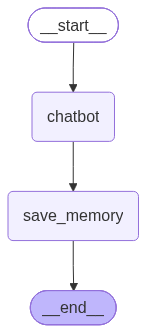

In [33]:
graph

In [34]:
# ============================================================
# CHAT FUNCTION
# ============================================================

def chat( user_id, thread_id, message):
    
    config = {
        "configurable": {

            "thread_id": thread_id,

            "user_id": user_id
        }
    }
    
    result = graph.invoke(

        {
            "messages": [
                {
                    "role": "user",
                    "content": message
                }
            ]
        },

        config=config
    )
    
    return (
        result["messages"][-1].content
    )

In [ ]:
# ============================================================
# TEST + MEMORY VISUALIZATION
# Run this cell immediately after the chat() function cell.
# ============================================================

test_user_id = "mahauser_test"
thread_1 = "memory_test_thread_1"
thread_2 = "memory_test_thread_2"

In [37]:
# ------------------------------------------------------------
# 1. STORE FACTS IN THREAD 1
# ------------------------------------------------------------

print("\nTEST 1 - Store user information")
print(
    chat(
        user_id=test_user_id,
        thread_id=thread_1,
        message=(
            "My name is maha. I prefer concise explanations, "
            "my favorite language is Python, and I am building "
            "an Agentic RAG project."
        )
    )
)



TEST 1 - Store user information

DEBUG INFO
Configurable : {'thread_id': 'memory_test_thread_1', 'user_id': 'maha_langgraph_test', '__pregel_runtime': Runtime(context=None, store=<langgraph.store.memory.InMemoryStore object at 0x000001A52F7A36F0>, stream_writer=<function Pregel.stream.<locals>.stream_writer at 0x000001A53167B380>, heartbeat=<function _no_op_heartbeat at 0x000001A52FF83CE0>, previous=None, execution_info=ExecutionInfo(checkpoint_id='1f1b6f60-2eb4-606f-8004-aea8452301cb', checkpoint_ns='chatbot:f7a5bac6-baf8-e65b-dc66-d32c504f171f', task_id='f7a5bac6-baf8-e65b-dc66-d32c504f171f', thread_id='memory_test_thread_1', run_id=None, node_attempt=1, node_first_attempt_time=1790130315.2377965), server_info=None, control=<langgraph.runtime.RunControl object at 0x000001A53137AEC0>), '__pregel_replay_state': None, '__pregel_task_id': 'f7a5bac6-baf8-e65b-dc66-d32c504f171f', '__pregel_send': <built-in method extend of collections.deque object at 0x000001A5323D1300>, '__pregel_read': 

In [38]:
# ------------------------------------------------------------
# 2. SAME THREAD: TEST SHORT-TERM MEMORY
# ------------------------------------------------------------

print("\nTEST 2 - Same-thread memory")
print(
    chat(
        user_id=test_user_id,
        thread_id=thread_1,
        message=(
            "What is my name, which language do I prefer, "
            "and what project am I building?"
        )
    )
)



TEST 2 - Same-thread memory

DEBUG INFO
Configurable : {'thread_id': 'memory_test_thread_1', 'user_id': 'maha_langgraph_test', '__pregel_runtime': Runtime(context=None, store=<langgraph.store.memory.InMemoryStore object at 0x000001A52F7A36F0>, stream_writer=<function Pregel.stream.<locals>.stream_writer at 0x000001A4EEDB1BC0>, heartbeat=<function _no_op_heartbeat at 0x000001A52FF83CE0>, previous=None, execution_info=ExecutionInfo(checkpoint_id='1f1b6f63-4236-6df5-8008-bd63ddd9ee03', checkpoint_ns='chatbot:5e2a5a93-5d23-8020-5e04-3c58c7a4350c', task_id='5e2a5a93-5d23-8020-5e04-3c58c7a4350c', thread_id='memory_test_thread_1', run_id=None, node_attempt=1, node_first_attempt_time=1790130397.8143222), server_info=None, control=<langgraph.runtime.RunControl object at 0x000001A4EED6EF80>), '__pregel_replay_state': None, '__pregel_task_id': '5e2a5a93-5d23-8020-5e04-3c58c7a4350c', '__pregel_send': <built-in method extend of collections.deque object at 0x000001A5316271F0>, '__pregel_read': func

In [ ]:
# ------------------------------------------------------------
# 3. NEW THREAD: TEST LONG-TERM MEMORY
# ------------------------------------------------------------

print("\nTEST 3 - Cross-thread long-term memory")
print(
    chat(
        user_id=test_user_id,
        thread_id=thread_2,
        message="What do you remember about me?"
    )
)

In [39]:
# ------------------------------------------------------------
# 4. VIEW SHORT-TERM MEMORY FOR A THREAD
# ------------------------------------------------------------

def show_thread_memory(user_id, thread_id):

    config = {
        "configurable": {
            "user_id": user_id,
            "thread_id": thread_id
        }
    }

    snapshot = graph.get_state(config)
    messages = snapshot.values.get("messages", [])

    print("\n" + "=" * 50)
    print(f"SHORT-TERM MEMORY | THREAD: {thread_id}")
    print("=" * 50)

    if not messages:
        print("No messages stored for this thread.")
        return

    for number, message in enumerate(messages, start=1):
        print(
            f"{number}. {message.type.title()}: "
            f"{message.content}"
        )


In [40]:
# ------------------------------------------------------------
# 5. VIEW LONG-TERM MEMORY FOR A USER
# ------------------------------------------------------------

def show_long_term_memory(user_id):

    memories = store.search(
        ("memories", user_id),
        limit=100
    )

    print("\n" + "=" * 50)
    print(f"LONG-TERM MEMORY | USER: {user_id}")
    print("=" * 50)

    if not memories:
        print("No long-term memories stored for this user.")
        return

    for number, memory in enumerate(memories, start=1):
        print(f"{number}. {memory.value}")

In [41]:
# Display both thread histories and extracted user memories.
show_thread_memory(test_user_id, thread_1)


SHORT-TERM MEMORY | THREAD: memory_test_thread_1
1. Human: My name is maha. I prefer concise explanations, my favorite language is Python, and I am building an Agentic RAG project.
2. Ai: Got it, Maha! If you need concise Python help or guidance on your Agentic RAG project, just ask. How can I assist you today?
3. Human: My name is maha. I prefer concise explanations, my favorite language is Python, and I am building an Agentic RAG project.
4. Ai: Understood, Maha. Ready to help with concise Python solutions for your Agentic RAG project. What do you need?
5. Human: What is my name, which language do I prefer, and what project am I building?
6. Ai: Your name is Maha, you prefer Python, and you are building an Agentic RAG project.


In [42]:
show_thread_memory(test_user_id, thread_2)


SHORT-TERM MEMORY | THREAD: memory_test_thread_2
No messages stored for this thread.


In [43]:
show_long_term_memory(test_user_id)


LONG-TERM MEMORY | USER: maha_langgraph_test
1. {'kind': 'Memory', 'content': {'content': "User's name is Maha."}}
2. {'kind': 'Memory', 'content': {'content': "User's favorite programming language is Python."}}
3. {'kind': 'Memory', 'content': {'content': 'User prefers concise explanations.'}}
4. {'kind': 'Memory', 'content': {'content': 'User is working on an Agentic RAG project.'}}


## Langgraph with persistant storage

this code builds an AI chatbot with two different memory systems

In [30]:

import sqlite3
import uuid

from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage

from langgraph.graph import (
    StateGraph,
    MessagesState,
    START,
    END
)

from langgraph.checkpoint.sqlite import (
    SqliteSaver
)

Short-term memory
→ LangGraph SqliteSaver
→ identified by thread_id
→ stores current conversation/thread state

Long-term memory
→ Custom SQLite database
→ identified by user_id
→ stores useful facts/preferences about the user

In [31]:

# ============================================================
# MODEL
# ============================================================

model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

In [32]:
# ============================================================
# SHORT-TERM MEMORY
# SQLITE CHECKPOINTER
# ============================================================
#
# Stores conversation state based on thread_id.
#
# Unlike InMemorySaver, this survives
# application restart.
# ============================================================

checkpoint_connection = sqlite3.connect("checkpoints.db",check_same_thread=False)
checkpointer = SqliteSaver(checkpoint_connection)

Allow this SQLite connection to be accessed from different threads.

In [34]:
# ============================================================
# LONG-TERM MEMORY
# CUSTOM SQLITE STORAGE
# ============================================================

class SQLiteLongTermMemory:

    def __init__(
        self,
        db_path="long_term_memory.db"
    ):

        self.db_path = db_path

        self.create_table()


    def connect(self):

        return sqlite3.connect(
            self.db_path
        )


    def create_table(self):

        with self.connect() as connection:

            connection.execute(
                """
                CREATE TABLE IF NOT EXISTS memories (

                    memory_id TEXT PRIMARY KEY,

                    user_id TEXT NOT NULL,

                    content TEXT NOT NULL,

                    created_at TIMESTAMP
                    DEFAULT CURRENT_TIMESTAMP

                )
                """
            )

            connection.commit()


    # --------------------------------------------------------
    # SAVE MEMORY
    # --------------------------------------------------------

    def add_memory(
        self,
        user_id,
        content
    ):

        # Avoid duplicate memories

        existing_memories = (
            self.get_memories(
                user_id
            )
        )

        if content in existing_memories:
            return


        memory_id = str(
            uuid.uuid4()
        )


        with self.connect() as connection:

            connection.execute(
                """
                INSERT INTO memories (
                    memory_id,
                    user_id,
                    content
                )

                VALUES (?, ?, ?)
                """,

                (
                    memory_id,
                    user_id,
                    content
                )
            )

            connection.commit()


    # --------------------------------------------------------
    # GET USER MEMORIES
    # --------------------------------------------------------

    def get_memories(
        self,
        user_id
    ):

        with self.connect() as connection:

            rows = connection.execute(
                """
                SELECT content

                FROM memories

                WHERE user_id = ?

                ORDER BY created_at
                """,

                (
                    user_id,
                )

            ).fetchall()


        return [
            row[0]
            for row in rows
        ]


In [35]:
# Create long-term memory object

long_term_memory = (SQLiteLongTermMemory())

In [36]:
long_term_memory.get_memories("test_user_1")

[]

In [37]:

# ============================================================
# MEMORY EXTRACTION SCHEMA
# ============================================================

class ExtractedMemories(BaseModel):

    memories: List[str] = Field(
        default_factory=list,
        description="""
        Important long-term information
        learned about the user.
        """
    )


In [ ]:

# ============================================================
# MEMORY EXTRACTION MODEL
# ============================================================

memory_extractor = (
    model.with_structured_output(
        ExtractedMemories
    )
)


In [39]:
# ============================================================
# AUTOMATIC MEMORY EXTRACTION
# ============================================================

def extract_memories(
    user_message
):

    prompt = f"""
Analyze the following user message.

User message:
{user_message}

Extract only useful long-term information
about the user.

Examples of useful memory:

- preferences
- personal facts
- goals
- projects
- skills
- important decisions

Do NOT store:

- greetings
- temporary questions
- general knowledge questions
- unnecessary conversation

If there is nothing useful to remember,
return an empty list.
"""


    result = memory_extractor.invoke(
        prompt
    )


    return result.memories


In [40]:
# ============================================================
# CHATBOT NODE
# ============================================================

def chatbot(
    state: MessagesState,
    config
):

    # --------------------------------------------------------
    # Get user_id
    # --------------------------------------------------------

    user_id = (
        config["configurable"]["user_id"]
    )


    # --------------------------------------------------------
    # Get long-term user memories
    # --------------------------------------------------------

    memories = (
        long_term_memory.get_memories(
            user_id
        )
    )


    if memories:

        memory_text = "\n".join(
            f"- {memory}"
            for memory in memories
        )

    else:

        memory_text = (
            "No saved long-term memories."
        )


    # --------------------------------------------------------
    # System message
    # --------------------------------------------------------

    system_message = SystemMessage(
        content=f"""
You are a helpful AI assistant.

Here is useful long-term information
about the user:

{memory_text}

Use these memories only when relevant.

The remaining messages contain the
conversation history for the current
thread.
"""
    )


    # --------------------------------------------------------
    # Generate response
    # --------------------------------------------------------

    response = model.invoke(
        [
            system_message,
            *state["messages"]
        ]
    )


    return {
        "messages": [
            response
        ]
    }


In [41]:
# ============================================================
# MEMORY UPDATE NODE
# ============================================================

def save_long_term_memory(
    state: MessagesState,
    config
):

    user_id = (
        config["configurable"]["user_id"]
    )


    # Find latest user message

    latest_user_message = None


    for message in reversed(
        state["messages"]
    ):

        if message.type == "human":

            latest_user_message = (
                message.content
            )

            break


    if not latest_user_message:

        return {}


    # --------------------------------------------------------
    # Automatically extract useful memories
    # --------------------------------------------------------

    memories = extract_memories(
        latest_user_message
    )


    # --------------------------------------------------------
    # Save memories into SQLite
    # --------------------------------------------------------

    for memory in memories:

        long_term_memory.add_memory(
            user_id,
            memory
        )


    return {}


In [42]:
# ============================================================
# BUILD LANGGRAPH
# ============================================================

builder = StateGraph(
    MessagesState
)


builder.add_node(
    "chatbot",
    chatbot
)


builder.add_node(
    "save_memory",
    save_long_term_memory
)


builder.add_edge(
    START,
    "chatbot"
)


builder.add_edge(
    "chatbot",
    "save_memory"
)


builder.add_edge(
    "save_memory",
    END
)


In [43]:
# ============================================================
# COMPILE GRAPH
# ============================================================

graph = builder.compile(
    checkpointer=checkpointer
)



In [ ]:
graph

In [46]:
# ============================================================
# CHAT FUNCTION
# ============================================================

def chat(
    user_id,
    thread_id,
    message
):

    config = {

        "configurable": {

            # WHO is the user?
            "user_id": user_id,

            # WHICH conversation?
            "thread_id": thread_id
        }
    }


    result = graph.invoke(

        {
            "messages": [
                {
                    "role": "user",
                    "content": message
                }
            ]
        },

        config=config
    )


    return (
        result["messages"][-1].content
    )


In [47]:
# ============================================================
# TEST
# ============================================================


# ------------------------------------------------------------
# THREAD 1
# ------------------------------------------------------------

print(
    chat(
        user_id="maha_123",
        thread_id="thread_1",
        message=(
            "My favorite programming "
            "language is Python."
        )
    )
)

NameError: name 'memory_extractor' is not defined

In [48]:

print(
    chat(
        user_id="maha_123",
        thread_id="thread_1",
        message=(
            "I am currently building "
            "an Agentic RAG application."
        )
    )
)


NameError: name 'memory_extractor' is not defined

In [49]:
# ------------------------------------------------------------
# SAME THREAD
# Checkpointer remembers conversation
# ------------------------------------------------------------

print(
    chat(
        user_id="maha_123",
        thread_id="thread_1",
        message=(
            "What project am I building?"
        )
    )
)


NameError: name 'memory_extractor' is not defined

In [ ]:
# ------------------------------------------------------------
# NEW THREAD
# Same user
#
# Thread history is different,
# but SQLite long-term memory is shared.
# ------------------------------------------------------------

print(
    chat(
        user_id="maha_123",
        thread_id="thread_2",
        message=(
            "Which programming language "
            "do I prefer?"
        )
    )
)

In [ ]:
# ------------------------------------------------------------
# DIFFERENT USER
# ------------------------------------------------------------

print(
    chat(
        user_id="user_456",
        thread_id="thread_1",
        message=(
            "Which programming language "
            "do I prefer?"
        )
    )
)

## Inspect Complete Persistent Memory

The helper below prints both memory layers used by this example:

- **Short-term/thread memory:** current state, complete checkpoint history, raw decoded checkpoint tuples, and SQLite checkpoint-table details.
- **Long-term/user memory:** every saved memory row for the selected `user_id` and the SQLite table details.

`thread_id` selects one conversation. `user_id` selects memories shared across that user's conversations. The database rows containing serialized checkpoint blobs are summarized by size; the decoded values are already shown through `checkpointer.list()`.

In [ ]:
# ============================================================
# COMPLETE SQLITE PERSISTENT-MEMORY INSPECTOR
# ============================================================

from contextlib import closing
from pathlib import Path
from pprint import pprint

from langchain_core.messages import (
    BaseMessage,
    message_to_dict
)


def _printable(value):
    """Convert LangChain messages and nested values to plain data."""

    if isinstance(value, BaseMessage):
        return message_to_dict(value)

    if isinstance(value, dict):
        return {
            key: _printable(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            _printable(item)
            for item in value
        ]

    return value


def _section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def print_sqlite_details(db_path, row_limit=10):
    """Print schema, columns, row counts, and readable row previews."""

    db_path = Path(db_path).resolve()
    print(f"Database: {db_path}")

    if not db_path.exists():
        print("Database file does not exist yet.")
        return

    with closing(sqlite3.connect(db_path)) as connection:
        connection.row_factory = sqlite3.Row

        tables = connection.execute(
            """
            SELECT name, sql
            FROM sqlite_master
            WHERE type = 'table'
            ORDER BY name
            """
        ).fetchall()

        for table in tables:
            table_name = table["name"]
            safe_table_name = table_name.replace("\"", "\"\"")

            print(f"\nTABLE: {table_name}")
            print("CREATE SQL:")
            print(table["sql"])

            columns = connection.execute(
                f'PRAGMA table_info("{safe_table_name}")'
            ).fetchall()
            print("COLUMNS:")
            pprint([dict(column) for column in columns])

            count = connection.execute(
                f'SELECT COUNT(*) FROM "{safe_table_name}"'
            ).fetchone()[0]
            print(f"ROW COUNT: {count}")

            rows = connection.execute(
                f'SELECT * FROM "{safe_table_name}" LIMIT ?',
                (row_limit,)
            ).fetchall()

            print(f"FIRST {min(row_limit, count)} ROW(S):")
            for row in rows:
                readable_row = {}
                for key in row.keys():
                    value = row[key]
                    if isinstance(value, bytes):
                        value = f"<BLOB: {len(value)} bytes>"
                    readable_row[key] = value
                pprint(readable_row)


def list_persistent_threads():
    """List every thread currently saved by SqliteSaver."""

    _section("ALL PERSISTED CHECKPOINT THREADS")

    try:
        rows = checkpoint_connection.execute(
            """
            SELECT
                thread_id,
                checkpoint_ns,
                COUNT(*) AS checkpoint_count,
                MAX(checkpoint_id) AS latest_checkpoint_id
            FROM checkpoints
            GROUP BY thread_id, checkpoint_ns
            ORDER BY thread_id, checkpoint_ns
            """
        ).fetchall()
    except sqlite3.OperationalError:
        print("No checkpoint table yet. Run chat() at least once.")
        return

    if not rows:
        print("No saved threads found.")
        return

    for row in rows:
        pprint({
            "thread_id": row[0],
            "checkpoint_namespace": row[1],
            "checkpoint_count": row[2],
            "latest_checkpoint_id": row[3]
        })


def inspect_persistent_memory(
    user_id,
    thread_id,
    history_limit=None,
    sqlite_row_limit=10
):
    """Print complete short-term and long-term persistent memory."""

    config = {
        "configurable": {
            "user_id": user_id,
            "thread_id": thread_id
        }
    }

    _section("IDENTITY / MEMORY SCOPE")
    pprint({
        "user_id (long-term scope)": user_id,
        "thread_id (checkpoint scope)": thread_id,
        "checkpoint_database": str(Path("checkpoints.db").resolve()),
        "long_term_database": str(Path(long_term_memory.db_path).resolve())
    })

    _section("CURRENT THREAD STATE - graph.get_state()")
    current_state = graph.get_state(config)
    pprint({
        "values": _printable(current_state.values),
        "next_nodes": current_state.next,
        "config": current_state.config,
        "metadata": current_state.metadata,
        "created_at": current_state.created_at,
        "parent_config": current_state.parent_config,
        "tasks": _printable(current_state.tasks)
    }, sort_dicts=False)

    _section("COMPLETE STATE HISTORY - newest to oldest")
    history = list(
        graph.get_state_history(
            config,
            limit=history_limit
        )
    )
    print(f"Total state snapshots shown: {len(history)}")

    for index, snapshot in enumerate(history, start=1):
        print(f"\n--- STATE SNAPSHOT {index} ---")
        pprint({
            "values": _printable(snapshot.values),
            "next_nodes": snapshot.next,
            "config": snapshot.config,
            "metadata": snapshot.metadata,
            "created_at": snapshot.created_at,
            "parent_config": snapshot.parent_config,
            "tasks": _printable(snapshot.tasks)
        }, sort_dicts=False)

    _section("RAW DECODED CHECKPOINT TUPLES - newest to oldest")
    checkpoint_tuples = list(
        checkpointer.list(
            config,
            limit=history_limit
        )
    )
    print(f"Total checkpoint tuples shown: {len(checkpoint_tuples)}")

    for index, item in enumerate(checkpoint_tuples, start=1):
        print(f"\n--- CHECKPOINT TUPLE {index} ---")
        pprint({
            "config": item.config,
            "checkpoint": _printable(item.checkpoint),
            "metadata": item.metadata,
            "parent_config": item.parent_config,
            "pending_writes": _printable(item.pending_writes)
        }, sort_dicts=False)

    _section("LONG-TERM MEMORY ROWS FOR USER")
    with closing(long_term_memory.connect()) as connection:
        connection.row_factory = sqlite3.Row
        memory_rows = connection.execute(
            """
            SELECT memory_id, user_id, content, created_at
            FROM memories
            WHERE user_id = ?
            ORDER BY created_at, memory_id
            """,
            (user_id,)
        ).fetchall()

    print(f"Total long-term memories: {len(memory_rows)}")
    for row in memory_rows:
        pprint(dict(row), sort_dicts=False)

    _section("CHECKPOINT SQLITE DATABASE DETAILS")
    print_sqlite_details(
        "checkpoints.db",
        row_limit=sqlite_row_limit
    )

    _section("LONG-TERM SQLITE DATABASE DETAILS")
    print_sqlite_details(
        long_term_memory.db_path,
        row_limit=sqlite_row_limit
    )


In [ ]:
# First see every thread saved in checkpoints.db
list_persistent_threads()

# Then inspect one thread + one user's long-term memory in full.
# Use history_limit=None for complete history, or e.g. 5 for latest five.
inspect_persistent_memory(
    user_id="sunny_123",
    thread_id="thread_1",
    history_limit=None,
    sqlite_row_limit=10
)

1. long term memory
2. short term memory
3. episodic memory
4. procedural memory
5. semantic memory

                         LANGMEM
                            │
          ┌─────────────────┼──────────────────┐
          │                 │                  │
          ▼                 ▼                  ▼
   Long-term Memory    Short-term Memory   Procedural Learning
          │                 │                  │
          │                 │                  │
 Semantic/Episodic     Summarization       Prompt Optimizer
          │
     ┌────┴─────┐
     │          │
 Hot Path   Background
 tools       extraction

LANGMEM
│
├── MEMORY CONTENT
│   ├── Semantic
│   │   ├── Collection
│   │   └── Profile
│   ├── Episodic
│   └── Procedural
│
├── MEMORY FORMATION
│   ├── Hot Path
│   │   ├── create_manage_memory_tool
│   │   └── create_search_memory_tool
│   │
│   └── Background
│       ├── create_memory_manager
│       ├── create_memory_store_manager
│       └── ReflectionExecutor
│
├── STORAGE
│   ├── BaseStore
│   ├── Namespaces
│   ├── Semantic Search
│   └── Persistent DB
│
├── SHORT-TERM CONTEXT
│   ├── summarize_messages
│   ├── SummarizationNode
│   ├── RunningSummary
│   └── Checkpointer
│
└── LEARNING / PROCEDURAL MEMORY
    ├── create_prompt_optimizer
    └── create_multi_prompt_optimizer

Is code me exactly kya ho raha hai?
                       USER
                        │
                 user_id = maha_123
                        │
          ┌─────────────┴─────────────┐
          │                           │
          ▼                           ▼
     thread_id                    Long-Term
          │                         Store
          ▼                           │
   Checkpointer                      │
          │                           │
          ▼                           ▼
Current Conversation          User Information
 Short-Term Memory            Long-Term Memory
          │                           │
          └──────────┬────────────────┘
                     ▼
                    LLM
                     │
                     ▼
                   Answer
                     │
                     ▼
             Memory Manager
                     │
                     ▼
          Extract useful memory
                     │
                     ▼
                   Store

Suppose Thread 1 me:

user_id   = maha_123
thread_id = thread_1

User:
My favorite programming language is Python.

save_memory node:

Conversation
     ↓
create_memory_store_manager
     ↓
LLM identifies useful information
     ↓
"User prefers Python"
     ↓
Store
     ↓
namespace:
("memories", "maha_123")

Ab new chat:

user_id   = maha_123
thread_id = thread_2

User:
Which programming language do I prefer?

Flow:

Current Query
     ↓
memory_manager.search()
     ↓
Long-Term Store
     ↓
"User prefers Python"
     ↓
System Prompt + Current Thread
     ↓
LLM
     ↓
You prefer Python.
Student ko ye 4 lines yaad karwao
Checkpointer
→ remembers the current conversation

thread_id
→ identifies the conversation

Store
→ keeps long-term information across conversations

user_id
→ identifies the user